01 · Build the TM 3-layer synthetic truth


1. Imports

In [145]:
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import json
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy

2. Paths & helpers

In [146]:
import paths
paths.ensure_dirs()

from paths import (
    REFERENCE_ZIP, REFERENCE_EXTRACT, REFERENCE_TEMPLATE,
    BASE_TRUTH_WS, CANDIDATE_DIR, FINAL_TRUTH_WS,
    TRUTH_RESULTS_DIR,
    PARAM_ENSEMBLE_NPZ, CANDIDATE_SUMMARY,
    HISTORY_OBS_CSV, FORECASTS_CSV, TRUTH_METADATA,
)

from tm_helpers import (
    active_cell_xy,
    draw_bounded_log_values,
    exponential_covariance,
    exponential_time_covariance,
    read_mf6_observation_csv,
    reset_directory,
    scatter_to_full_grid,
    stable_cholesky,
)

3. Extract the reference model

In [147]:
if not REFERENCE_TEMPLATE.exists():
    with zipfile.ZipFile(REFERENCE_ZIP) as archive:
        archive.extractall(REFERENCE_EXTRACT)

if not REFERENCE_TEMPLATE.exists():
    raise FileNotFoundError("The extracted ZIP does not contain template/.")

4. Load the reference MODFLOW 6 simulation

In [148]:
reference_sim = flopy.mf6.MFSimulation.load(
    sim_ws=str(REFERENCE_TEMPLATE),
    verbosity_level=0,
)
reference_gwf = reference_sim.get_model()

5. Grid dimensions and model unit system

In [149]:
nlay = int(reference_gwf.dis.nlay.array)
nrow = int(reference_gwf.dis.nrow.array)
ncol = int(reference_gwf.dis.ncol.array)
delr = float(reference_gwf.dis.delr.array[0])
delc = float(reference_gwf.dis.delc.array[0])
print(nlay, nrow, ncol, delr, delc)

3 40 20 250.0 250.0


6. Copy the reference geometry arrays

In [150]:
top = reference_gwf.dis.top.array.copy()
botm = reference_gwf.dis.botm.array.copy()
idomain = reference_gwf.dis.idomain.array.copy().astype(int)
strt = reference_gwf.ic.strt.array.copy()

7. Observation and forecast cell locations

In [151]:
GW_1 = (2, 2, 9)    # layer 3, row 3, col 10; 0-based
GW_2 = (2, 33, 7)   # layer 3, row 34, col 8; 0-based
GW_3 = (0, 9, 1)    # layer 1, row 10, col 2; 0-based

8. Visualize the three-layer active model domain

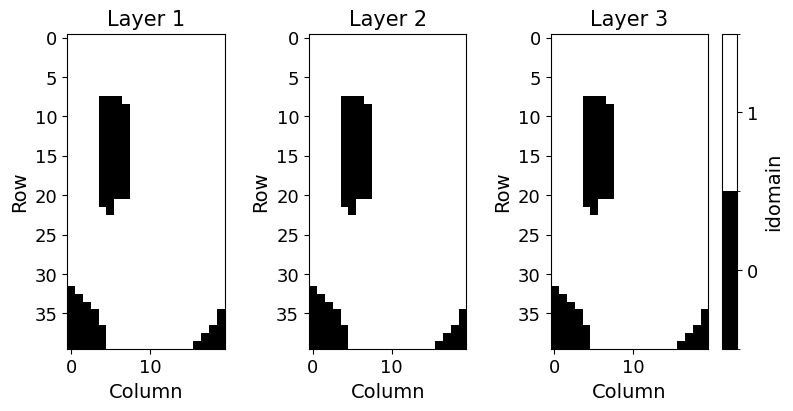

In [152]:
cmap = ListedColormap(["black", "white"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(8, 4), constrained_layout=True)

for lay, ax in enumerate(axes):
    im = ax.imshow(
        idomain[lay],
        origin="upper",
        cmap=cmap,
        norm=norm,
        interpolation="none",
        aspect="equal"
    )

    ax.set_title(f"Layer {lay+1}")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

cbar = fig.colorbar(
    im,
    ax=axes,
    ticks=[0, 1],
    pad=0.02
)
cbar.set_ticklabels(["0", "1"])
cbar.set_label("idomain")

plt.show()

9. Stress-period schedule from the reference model

In [153]:
reference_perioddata = reference_sim.tdis.perioddata.get_data()
tdis_perioddata = [
    (float(row["perlen"]), int(row["nstp"]), float(row["tsmult"]))
    for row in reference_perioddata
]
nper = len(tdis_perioddata)

10. Stress-period labels and month-end dates

In [154]:
sp = np.arange(1, nper + 1)
sp_dates = pd.DatetimeIndex(
    [pd.Timestamp("2015-12-31")] + list(pd.date_range("2016-01-31", periods=24, freq="ME"))
)

11. TM (p3,4) observation and forecast timing

In [155]:
HISTORY_SP = np.arange(2, 14)
HEADWATER_FORECAST_SP = 22
TAILWATER_FORECAST_SP = 13
GW3_FORECAST_SP = 22

12. Reference baseline recharge series

In [156]:
reference_rch = reference_gwf.rcha.recharge.get_data()
reference_rch_values = np.empty(nper, dtype=float)

for kper in range(nper):
    value = reference_rch[kper]
    if np.ndim(value) == 0:
        reference_rch_values[kper] = float(value)
    else:
        reference_rch_values[kper] = float(np.nanmean(value[idomain[0] > 0]))

13. Reference well cells and baseline pumping series

In [157]:
reference_wel = reference_gwf.wel.stress_period_data.get_data()
reference_well_cells = [tuple(record["cellid"]) for record in reference_wel[0]]
reference_well_rates = np.empty((len(reference_well_cells), nper), dtype=float)

for kper in range(nper):
    period_records = reference_wel[kper]
    reference_well_rates[:, kper] = [-float(record["q"]) for record in period_records]

14. Plot the fixed reference stress series

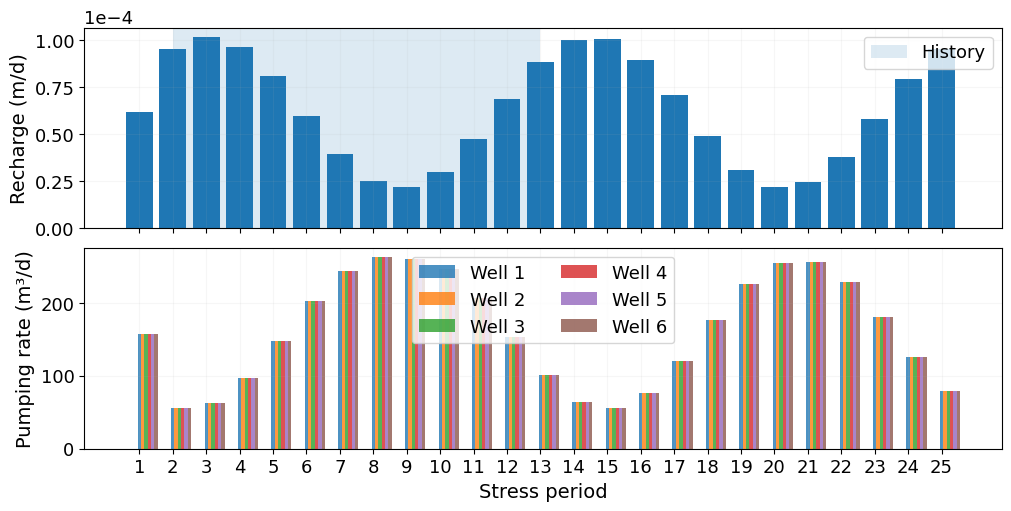

In [158]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, constrained_layout=True)

axes[0].bar(sp, reference_rch_values, width=0.8)
axes[0].set_ylabel("Recharge (m/d)")
axes[0].axvspan(2, 13, alpha=0.15, label="History")
axes[0].legend()
axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

for well_index in range(reference_well_rates.shape[0]):
    axes[1].bar(
        sp + well_index * 0.1,
        reference_well_rates[well_index],
        width=0.1,
        label=f"Well {well_index + 1}",
        alpha=0.8
    )

axes[1].set_xlabel("Stress period")
axes[1].set_ylabel("Pumping rate (m³/d)")
axes[1].legend(ncol=2)

axes[1].set_xticks(sp)

for ax in axes:
    ax.grid(True, linestyle="-", alpha=0.1)

plt.show()

15. Reference GHB data

In [159]:
reference_ghb = reference_gwf.ghb.stress_period_data.get_data(0)
ghb_spd = [
    [tuple(record["cellid"]), float(record["bhead"]), float(record["cond"])]
    for record in reference_ghb
]

16. Reference SFR geometry and routing

In [160]:
reference_sfr_packagedata = reference_gwf.sfr.packagedata.get_data().copy()
reference_sfr_connectiondata = reference_gwf.sfr.connectiondata.get_data().copy()
reference_sfr_perioddata = reference_gwf.sfr.perioddata.get_data().copy()

nreaches = len(reference_sfr_packagedata)

17. Apply the TM 20-reach / 20-reach forecast split

In [161]:
sfr_packagedata = reference_sfr_packagedata.copy()
sfr_packagedata["boundname"][:20] = "headwater_tm"
sfr_packagedata["boundname"][20:] = "tailwater_tm" 

18. Spatial-property metadata from the TM bounds

In [162]:
property_specs = [
    ("hk_l1", 0, "K",   0.3,   30.0),
    ("hk_l2", 1, "K",   0.03,   3.0),
    ("hk_l3", 2, "K",   3.0, 300.0),
    ("vk_l1", 0, "K33", 0.03,   3.0),
    ("vk_l2", 1, "K33", 0.003,  0.3),
    ("vk_l3", 2, "K33", 0.3,   30.0),
    ("ss_l1", 0, "SS",  1.0e-7, 1.0e-5),
    ("ss_l2", 1, "SS",  1.0e-7, 1.0e-5),
    ("ss_l3", 2, "SS",  1.0e-7, 1.0e-5),
    ("sy_l1", 0, "SY",  0.001,  0.1),
]

property_table = pd.DataFrame(property_specs, columns=["name", "layer", "mf6_input", "lower", "upper"])
property_table["prior_mean"] = np.sqrt(property_table["lower"] * property_table["upper"])
property_table["log10_std"] = (np.log10(property_table["upper"]) - np.log10(property_table["lower"])) / 4.0
property_table

,name,layer,mf6_input,lower,upper,prior_mean,log10_std
0,hk_l1,0,K,3.000000e-01,30.00000,3.000000,0.5
1,hk_l2,1,K,3.000000e-02,3.00000,0.300000,0.5
2,hk_l3,2,K,3.000000e+00,300.00000,30.000000,0.5
3,vk_l1,0,K33,3.000000e-02,3.00000,0.300000,0.5
4,vk_l2,1,K33,3.000000e-03,0.30000,0.030000,0.5
5,vk_l3,2,K33,3.000000e-01,30.00000,3.000000,0.5
6,ss_l1,0,SS,1.000000e-07,0.00001,0.000001,0.5
7,ss_l2,1,SS,1.000000e-07,0.00001,0.000001,0.5
8,ss_l3,2,SS,1.000000e-07,0.00001,0.000001,0.5
9,sy_l1,0,SY,1.000000e-03,0.10000,0.010000,0.5


19. Spatial covariance range

In [163]:
SPATIAL_RANGE_M = 1000.0  # four 250-m cells; preserves the TM four-cell correlation scale

20. Active-cell coordinates for each layer

In [164]:
active_index = {}
active_xy = {}

for lay in range(nlay):
    row, col, xy = active_cell_xy(idomain[lay], delr, delc)
    active_index[lay] = (row, col)
    active_xy[lay] = xy

21. Build the three spatial correlation matrices

In [165]:
spatial_cholesky = {}

for lay in range(nlay):
    nactive = active_xy[lay].shape[0]
    unit_std = np.ones(nactive, dtype=float)
    covariance = exponential_covariance(active_xy[lay], SPATIAL_RANGE_M, unit_std)
    spatial_cholesky[lay] = stable_cholesky(covariance)

22. Time covariance range for recharge and pumping

In [166]:
TEMPORAL_RANGE_MONTHS = 3.0

23. Reference PEST parameter table (time-series bounds only)

In [167]:
reference_par_data = pd.read_csv(REFERENCE_TEMPLATE / "truth.par_data.csv")

24. Recharge parameter means and transformed bounds

In [168]:
rch_par = reference_par_data.loc[reference_par_data["pargp"] == "rch"].copy()
rch_par = rch_par.sort_values("kper")

rch_mean_log10 = rch_par["parval1_trans"].to_numpy(dtype=float)
rch_lower_log10 = rch_par["parlbnd_trans"].to_numpy(dtype=float)
rch_upper_log10 = rch_par["parubnd_trans"].to_numpy(dtype=float)
rch_log10_std = (rch_upper_log10 - rch_lower_log10) / 4.0

25. Recharge temporal covariance and Cholesky factor

In [169]:
rch_covariance = exponential_time_covariance(nper, TEMPORAL_RANGE_MONTHS, rch_log10_std)
rch_cholesky = stable_cholesky(rch_covariance)

26. Pumping parameter means and transformed bounds

In [170]:
wel_par = reference_par_data.loc[
    reference_par_data["pargp"].str.startswith("welflux_")
].copy()

wel_par = wel_par.sort_values(["kper", "parnme"])

well_mean_log10 = np.empty((len(reference_well_cells), nper), dtype=float)
well_lower_log10 = np.empty_like(well_mean_log10)
well_upper_log10 = np.empty_like(well_mean_log10)

for kper in range(nper):
    rows = wel_par.loc[wel_par["kper"] == kper]

    well_mean_log10[:, kper] = np.log10(rows["parval1"].to_numpy(dtype=float))
    well_lower_log10[:, kper] = np.log10(rows["parlbnd"].to_numpy(dtype=float))
    well_upper_log10[:, kper] = np.log10(rows["parubnd"].to_numpy(dtype=float))

well_log10_std = (well_upper_log10 - well_lower_log10) / 4.0

27. Pumping temporal covariance and Cholesky factor

In [171]:
well_cholesky = []
for well_index in range(len(reference_well_cells)):
    covariance = exponential_time_covariance(
        nper,
        TEMPORAL_RANGE_MONTHS,
        well_log10_std[well_index],
    )
    well_cholesky.append(stable_cholesky(covariance))

28. Random seed and number of candidate truth realizations

In [172]:
RANDOM_SEED = 42
N_REALIZATIONS = 300
rng = np.random.default_rng(RANDOM_SEED)

30. Allocate the 300 spatial truth-field arrays

In [173]:
hk_ensemble = np.empty((N_REALIZATIONS, nlay, nrow, ncol), dtype=float)
vk_ensemble = np.empty((N_REALIZATIONS, nlay, nrow, ncol), dtype=float)
ss_ensemble = np.empty((N_REALIZATIONS, nlay, nrow, ncol), dtype=float)
sy_ensemble = np.empty((N_REALIZATIONS, nrow, ncol), dtype=float)

31.# Draw the cell-by-cell `K` truth fields

In [174]:
for lay, spec_name in enumerate(["hk_l1", "hk_l2", "hk_l3"]):
    spec = property_table.loc[property_table["name"] == spec_name].iloc[0]
    row, col = active_index[lay]
    nactive = len(row)
    mean_log10 = np.full(nactive, np.log10(spec.prior_mean), dtype=float)
    lower_log10 = np.full(nactive, np.log10(spec.lower), dtype=float)
    upper_log10 = np.full(nactive, np.log10(spec.upper), dtype=float)

    for realization in range(N_REALIZATIONS):
        active_log10 = draw_bounded_log_values(
            rng, mean_log10, spatial_cholesky[lay] * float(spec.log10_std), lower_log10, upper_log10
        )
        hk_ensemble[realization, lay] = scatter_to_full_grid(
            10.0 ** active_log10, row, col, (nrow, ncol), spec.prior_mean
        )

32. Draw the cell-by-cell `K33` truth fields

In [175]:
for lay, spec_name in enumerate(["vk_l1", "vk_l2", "vk_l3"]):
    spec = property_table.loc[property_table["name"] == spec_name].iloc[0]
    row, col = active_index[lay]
    nactive = len(row)
    mean_log10 = np.full(nactive, np.log10(spec.prior_mean), dtype=float)
    lower_log10 = np.full(nactive, np.log10(spec.lower), dtype=float)
    upper_log10 = np.full(nactive, np.log10(spec.upper), dtype=float)

    for realization in range(N_REALIZATIONS):
        active_log10 = draw_bounded_log_values(
            rng, mean_log10, spatial_cholesky[lay] * float(spec.log10_std), lower_log10, upper_log10
        )
        vk_ensemble[realization, lay] = scatter_to_full_grid(
            10.0 ** active_log10, row, col, (nrow, ncol), spec.prior_mean
        )

33. Draw the cell-by-cell `Ss` truth fields

In [176]:
for lay, spec_name in enumerate(["ss_l1", "ss_l2", "ss_l3"]):
    spec = property_table.loc[property_table["name"] == spec_name].iloc[0]
    row, col = active_index[lay]
    nactive = len(row)
    mean_log10 = np.full(nactive, np.log10(spec.prior_mean), dtype=float)
    lower_log10 = np.full(nactive, np.log10(spec.lower), dtype=float)
    upper_log10 = np.full(nactive, np.log10(spec.upper), dtype=float)

    for realization in range(N_REALIZATIONS):
        active_log10 = draw_bounded_log_values(
            rng, mean_log10, spatial_cholesky[lay] * float(spec.log10_std), lower_log10, upper_log10
        )
        ss_ensemble[realization, lay] = scatter_to_full_grid(
            10.0 ** active_log10, row, col, (nrow, ncol), spec.prior_mean
        )

34. Draw the layer-1 `Sy` truth fields

In [177]:
sy_spec = property_table.loc[property_table["name"] == "sy_l1"].iloc[0]
row, col = active_index[0]
nactive = len(row)
mean_log10 = np.full(nactive, np.log10(sy_spec.prior_mean), dtype=float)
lower_log10 = np.full(nactive, np.log10(sy_spec.lower), dtype=float)
upper_log10 = np.full(nactive, np.log10(sy_spec.upper), dtype=float)

for realization in range(N_REALIZATIONS):
    active_log10 = draw_bounded_log_values(
        rng, mean_log10, spatial_cholesky[0] * float(sy_spec.log10_std), lower_log10, upper_log10
    )
    sy_ensemble[realization] = scatter_to_full_grid(
        10.0 ** active_log10, row, col, (nrow, ncol), sy_spec.prior_mean
    )

35. Allocate the temporally correlated recharge and pumping truth arrays

In [178]:
recharge_ensemble = np.empty((N_REALIZATIONS, nper), dtype=float)
pumping_ensemble = np.empty((N_REALIZATIONS, len(reference_well_cells), nper), dtype=float)

36. Draw the 25-period recharge truth series

In [179]:
for realization in range(N_REALIZATIONS):
    rch_log10 = draw_bounded_log_values(
        rng,
        rch_mean_log10,
        rch_cholesky,
        rch_lower_log10,
        rch_upper_log10,
    )
    recharge_ensemble[realization] = 10.0 ** rch_log10

37. Draw independent, temporally correlated pumping series for the six wells

In [180]:
for realization in range(N_REALIZATIONS):
    for well_index in range(len(reference_well_cells)):
        well_log10 = draw_bounded_log_values(
            rng,
            well_mean_log10[well_index],
            well_cholesky[well_index],
            well_lower_log10[well_index],
            well_upper_log10[well_index],
        )
        pumping_ensemble[realization, well_index] = 10.0 ** well_log10

38. Persist the random truth draws before running MODFLOW 6

In [181]:
np.savez_compressed(
    PARAM_ENSEMBLE_NPZ,
    hk=hk_ensemble,
    vk=vk_ensemble,
    ss=ss_ensemble,
    sy=sy_ensemble,
    recharge=recharge_ensemble,
    pumping=pumping_ensemble,
)

39. Create one base Flopy model workspace

In [182]:
MODEL_NAME = "frb3l_truth"
MF6_EXE = "mf6"
reset_directory(BASE_TRUTH_WS)

WindowsPath('C:/workspace/gwmodeling/model_enhanced_fr/runs/truth/base_truth_template')

40. Create the MODFLOW 6 simulation, TDIS, and IMS

In [183]:
sim = flopy.mf6.MFSimulation(
    sim_name=MODEL_NAME,
    version="mf6",
    exe_name=MF6_EXE,
    sim_ws=str(BASE_TRUTH_WS),
)

In [184]:
flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=nper,
    perioddata=tdis_perioddata,
)

package_name = frb3l_truth.tdis
filename = frb3l_truth.tdis
package_type = tdis
model_or_simulation_package = simulation
simulation_name = frb3l_truth

Block options
--------------------
time_units
{internal}
('days')


Block dimensions
--------------------
nper
{internal}
(25)


Block perioddata
--------------------
perioddata
{internal}
(rec.array([( 1., 1, 1.), (31., 1, 1.), (29., 1, 1.), (31., 1, 1.),
           (30., 1, 1.), (31., 1, 1.), (30., 1, 1.), (31., 1, 1.),
           (31., 1, 1.), (30., 1, 1.), (31., 1, 1.), (30., 1, 1.),
           (31., 1, 1.), (31., 1, 1.), (28., 1, 1.), (31., 1, 1.),
           (30., 1, 1.), (31., 1, 1.), (30., 1, 1.), (31., 1, 1.),
           (31., 1, 1.), (30., 1, 1.), (31., 1, 1.), (30., 1, 1.),
           (31., 1, 1.)],
          dtype=[('perlen', '<f8'), ('nstp', '<i8'), ('tsmult', '<f8')]))



In [185]:
flopy.mf6.ModflowIms(
    sim,
    complexity="SIMPLE",
    outer_dvclose=0.01,
    outer_maximum=100,
    under_relaxation="DBD",
    under_relaxation_theta=0.85,
    under_relaxation_kappa=1.0e-5,
    under_relaxation_gamma=0.0,
    under_relaxation_momentum=0.1,
    backtracking_number=50,
    backtracking_tolerance=1.1,
    backtracking_reduction_factor=0.7,
    backtracking_residual_limit=100.0,
    inner_maximum=50,
    inner_dvclose=1.0e-4,
    rcloserecord=[0.1, "strict"],
    linear_acceleration="BICGSTAB",
    preconditioner_levels=1,
    preconditioner_drop_tolerance=0.001,
    number_orthogonalizations=2,
    reordering_method="RCM",
)

package_name = ims_-1
filename = frb3l_truth.ims
package_type = ims
model_or_simulation_package = simulation
simulation_name = frb3l_truth

Block options
--------------------
complexity
{internal}
('simple')


Block nonlinear
--------------------
outer_dvclose
{internal}
(0.01)

outer_maximum
{internal}
(100)

under_relaxation
{internal}
('dbd')

under_relaxation_gamma
{internal}
(0.0)

under_relaxation_theta
{internal}
(0.85)

under_relaxation_kappa
{internal}
(1e-05)

under_relaxation_momentum
{internal}
(0.1)

backtracking_number
{internal}
(50)

backtracking_tolerance
{internal}
(1.1)

backtracking_reduction_factor
{internal}
(0.7)

backtracking_residual_limit
{internal}
(100.0)


Block linear
--------------------
inner_maximum
{internal}
(50)

inner_dvclose
{internal}
(0.0001)

rcloserecord
{internal}
(rec.array([('inner_rclose', 0.1, 'strict')],
          dtype=[('inner_rclose_label', 'O'), ('inner_rclose', '<f8'), ('rclose_option', 'O')]))

linear_acceleration
{internal}
('bicgs

41. Create the groundwater-flow model

In [186]:
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname=MODEL_NAME,
    save_flows=True,
    newtonoptions="NEWTON",
)

42. DIS and IC: geometry is copied from the reference model

In [187]:
flopy.mf6.ModflowGwfdis(
    gwf,
    length_units="METERS",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    idomain=idomain,
)

flopy.mf6.ModflowGwfic(gwf, strt=strt)

package_name = ic
filename = frb3l_truth.ic
package_type = ic
model_or_simulation_package = model
model_name = frb3l_truth

Block griddata
--------------------
strt
Layer_1{internal}
(array([[  39.43086,   39.36268,   39.21904,   39.00412,   38.77077,
          38.50557,   38.18176,   37.9013 ,   37.56582,   37.22559,
          36.89874,   36.57523,   36.24156,   35.8782 ,   35.50056,
          35.06069,   35.20473,   35.27559,   35.32089,   35.34552],
       [  39.44527,   39.3694 ,   39.2267 ,   39.00596,   38.78024,
          38.51054,   38.18633,   37.88638,   37.55757,   37.20073,
          36.87487,   36.55574,   36.22322,   35.8616 ,   35.49544,
          35.05295,   35.19559,   35.26754,   35.3132 ,   35.33702],
       [  39.469  ,   39.39716,   39.24449,   39.01912,   38.79418,
          38.51512,   38.17535,   37.87197,   37.52209,   37.17342,
          36.83224,   36.51633,   36.1836 ,   35.83557,   35.4813 ,
          35.04065,   35.18043,   35.25023,   35.29593,   35.31992

43. NPF: initialize the base template with realization 0

In [188]:
icelltype = np.array([1, 0, 0], dtype=int)

flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=icelltype,
    k=hk_ensemble[0],
    k33=vk_ensemble[0],
    save_flows=True,
    save_specific_discharge=True,
)

package_name = npf
filename = frb3l_truth.npf
package_type = npf
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
save_flows
{internal}
(True)

save_specific_discharge
{internal}
(True)


Block griddata
--------------------
icelltype
Layer_1{constant 1}
Layer_2{constant 0}
Layer_3{constant 0}

k
Layer_1{internal}
(array([[ 4.2606886 ,  1.86038183,  3.55527691,  6.75389269,  1.37937402,
         0.63960726,  0.98736869,  1.00474165,  1.26435601,  0.82666546,
         2.07475013,  3.94762016,  3.89650174,  8.30041787,  9.2888558 ,
         3.88941078,  4.79285427,  2.16195362,  4.38359898,  3.8881109 ],
       [ 2.98080524,  1.77548633,  5.43459272,  3.79867689,  1.46511736,
         0.80774661,  1.27027394,  1.54885794,  1.80329894,  2.07265308,
         9.05564761,  5.09278865,  4.01529218,  3.64071136,  7.22641143,
         9.99673748,  5.18711478,  2.26874275,  1.88424348,  4.11375557],
       [ 4.68642156,  4.65752026,  2.91319024,  3.

44. STO: initialize the base template with realization 0

In [189]:
iconvert = np.array([1, 0, 0], dtype=int)
sy_first = np.stack([
    sy_ensemble[0],
    np.zeros((nrow, ncol), dtype=float),
    np.zeros((nrow, ncol), dtype=float),
])

flopy.mf6.ModflowGwfsto(
    gwf,
    iconvert=iconvert,
    ss=ss_ensemble[0],
    sy=sy_first,
    steady_state={0: True},
    transient={1: True},
    save_flows=True,
)

package_name = sto
filename = frb3l_truth.sto
package_type = sto
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
save_flows
{internal}
(True)


Block griddata
--------------------
iconvert
Layer_1{constant 1}
Layer_2{constant 0}
Layer_3{constant 0}

ss
Layer_1{internal}
(array([[1.23790629e-07, 5.02106655e-07, 8.31360861e-07, 9.95690201e-07,
        6.00800975e-07, 9.27984197e-07, 7.51419197e-07, 4.07690044e-07,
        3.05160129e-07, 1.07400213e-07, 1.00000000e-07, 1.28574964e-07,
        3.93536460e-07, 3.07084148e-07, 7.53972822e-07, 4.57544090e-07,
        1.00000000e-07, 1.88014748e-07, 1.00000000e-07, 3.02449699e-07],
       [3.75613025e-07, 9.82845763e-07, 1.45898372e-06, 6.79970504e-07,
        5.62112916e-07, 7.50626917e-07, 4.14125826e-07, 5.79186183e-07,
        4.59662064e-07, 2.87781367e-07, 2.35335627e-07, 1.00000000e-07,
        1.03735357e-07, 2.02706168e-07, 1.83118100e-07, 3.53509876e-07,
        1.02994627e-07, 1.4948

45. GHB: use the reference row-40 boundary cells

In [190]:
flopy.mf6.ModflowGwfghb(
    gwf,
    stress_period_data={0: ghb_spd},
    save_flows=True,
    print_input=True,
    print_flows=True,
    pname="GHB",
)

package_name = ghb
filename = frb3l_truth.ghb
package_type = ghb
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
print_input
{internal}
(True)

print_flows
{internal}
(True)

save_flows
{internal}
(True)


Block period
--------------------
stress_period_data
{internal}
(    cellid_layer  cellid_row  cellid_column  bhead  cond
0              0          39              5   33.5  70.0
1              0          39              6   33.5  70.0
2              0          39              7   33.5  70.0
3              0          39              8   33.5  70.0
4              0          39              9   33.5  70.0
5              0          39             10   33.5  70.0
6              0          39             11   33.5  70.0
7              0          39             12   33.5  70.0
8              0          39             13   33.5  70.0
9              0          39             14   33.5  70.0
10             1          39              5   33.5  7

46. WEL: initialize the base template with realization 0

In [191]:
well_spd = {}
for kper in range(nper):
    well_spd[kper] = [
        [reference_well_cells[well_index], -pumping_ensemble[0, well_index, kper]]
        for well_index in range(len(reference_well_cells))
    ]

flopy.mf6.ModflowGwfwel(
    gwf,
    stress_period_data=well_spd,
    save_flows=True,
    print_input=True,
    print_flows=True,
    pname="WEL",
)

package_name = wel
filename = frb3l_truth.wel
package_type = wel
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
print_input
{internal}
(True)

print_flows
{internal}
(True)

save_flows
{internal}
(True)


Block period
--------------------
stress_period_data
{internal}
(   cellid_layer  cellid_row  cellid_column           q
0             2           9             16  -77.312153
1             2          11             13 -172.320507
2             2          20             14 -173.111270
3             2          26             10 -292.592588
4             2          29              6 -138.236595
5             2          34             12 -298.751162)
...
and 24 additional data blocks


47. RCHA: initialize the base template with realization 0

In [192]:
rch_spd = {}
for kper in range(nper):
    rch_spd[kper] = np.where(idomain[0] > 0, recharge_ensemble[0, kper], 0.0)

flopy.mf6.ModflowGwfrcha(
    gwf,
    readasarrays=True,
    recharge=rch_spd,
    save_flows=True,
    pname="RCHA",
)

package_name = rcha
filename = frb3l_truth.rcha
package_type = rcha
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
readasarrays
{internal}
(True)

save_flows
{internal}
(True)


Block period
--------------------
irch
None
recharge
{internal}
(array([[4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05],
       [4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.01518218e-05,
        4.01518218e-05, 4.01518218e-05, 4.01518218e-05, 4.

48. SFR: reference geometry and forcing, TM forecast reach split

In [193]:
sfr_observations = {
    "truth_sfr_obs.csv": [
        ("headwater_exchange", "SFR", "headwater_tm"),
        ("tailwater_exchange", "SFR", "tailwater_tm"),
        ("sw_1", "INFLOW", 39),
    ]
}

flopy.mf6.ModflowGwfsfr(
    gwf,
    nreaches=nreaches,
    packagedata=sfr_packagedata,
    connectiondata=reference_sfr_connectiondata,
    perioddata=reference_sfr_perioddata,
    boundnames=True,
    unit_conversion=86400.0,
    maximum_depth_change=1.0e-4,
    save_flows=True,
    observations=sfr_observations,
    pname="SFR",
)

package_name = sfr
filename = frb3l_truth.sfr
package_type = sfr
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
boundnames
{internal}
(True)

save_flows
{internal}
(True)

obs_filerecord
{internal}
(rec.array([('frb3l_truth.sfr.obs',)],
          dtype=[('obs6_filename', 'O')]))

maximum_depth_change
{internal}
(0.0001)

unit_conversion
{internal}
(86400.0)


Block dimensions
--------------------
nreaches
{internal}
(40)


Block packagedata
--------------------
packagedata
{internal}
(rec.array([( 0, (0, 0, 15), 250., 5., 5.e-05, 34.     , 1., 0.1, '0.3000000e-01', 1, 1., 0, 'headwater_tm'),
           ( 1, (0, 1, 15), 250., 5., 5.e-05, 33.98718, 1., 0.1, '0.3000000e-01', 2, 1., 0, 'headwater_tm'),
           ( 2, (0, 2, 15), 250., 5., 5.e-05, 33.97436, 1., 0.1, '0.3000000e-01', 2, 1., 0, 'headwater_tm'),
           ( 3, (0, 3, 15), 250., 5., 5.e-05, 33.96154, 1., 0.1, '0.3000000e-01', 2, 1., 0, 'headwater_tm'),
           ( 4, (0, 4, 1

49. Head observations: two history locations plus the `gw_3` forecast location

In [194]:
head_observations = {
    "truth_heads_obs.csv": [
        ("gw_1", "HEAD", GW_1),
        ("gw_2", "HEAD", GW_2),
        ("gw_3", "HEAD", GW_3),
    ]
}

flopy.mf6.ModflowUtlobs(
    gwf,
    print_input=True,
    continuous=head_observations,
)

package_name = obs_1
filename = frb3l_truth.obs
package_type = obs
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
print_input
{internal}
(True)


Block continuous
--------------------
continuous
{internal}
(rec.array([('gw_1', 'HEAD', (2, 2, 9), None),
           ('gw_2', 'HEAD', (2, 33, 7), None),
           ('gw_3', 'HEAD', (0, 9, 1), None)],
          dtype=[('obsname', 'O'), ('obstype', 'O'), ('id', 'O'), ('id2', 'O')]))



50. Output control

In [195]:
flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{MODEL_NAME}.hds",
    budget_filerecord=f"{MODEL_NAME}.cbc",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("BUDGET", "ALL")],
)

package_name = oc
filename = frb3l_truth.oc
package_type = oc
model_or_simulation_package = model
model_name = frb3l_truth

Block options
--------------------
budget_filerecord
{internal}
(rec.array([('frb3l_truth.cbc',)],
          dtype=[('budgetfile', 'O')]))

head_filerecord
{internal}
(rec.array([('frb3l_truth.hds',)],
          dtype=[('headfile', 'O')]))


Block period
--------------------
saverecord
{internal}
(rec.array([('HEAD', 'ALL', None), ('BUDGET', 'ALL', None)],
          dtype=[('rtype', 'O'), ('ocsetting', 'O'), ('ocsetting_data', 'O')]))

printrecord
{internal}
(rec.array([('BUDGET', 'ALL', None)],
          dtype=[('rtype', 'O'), ('ocsetting', 'O'), ('ocsetting_data', 'O')]))



51. Write the base Flopy model

In [196]:
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model frb3l_truth...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package ghb...
INFORMATION: maxbound in ('', 'ghb', 'dimensions') changed to 30 based on size of stress_period_data
    writing package wel...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 6 based on size of stress_period_data
    writing package rcha...
    writing package sfr...
    writing package obs_0...
    writing package obs_1...
    writing package oc...


52. Run all 300 candidates through one reusable scratch workspace

Each candidate reloads the base template, overwrites the six truth inputs with its own
realization, and runs MODFLOW 6 **in a single scratch workspace that is reused every
iteration**. Only the three selection scalars are kept in memory; no per-candidate folders
are left behind. The full parameter draws already live in `truth_parameter_ensembles.npz`.

In [197]:
summary_records = []

for realization in range(N_REALIZATIONS):
    reset_directory(CANDIDATE_DIR)   # ← 매 후보마다 스크래치를 비우고 시작 (중복 등록 방지)

    candidate_sim = flopy.mf6.MFSimulation.load(
        sim_ws=str(BASE_TRUTH_WS),
        verbosity_level=0,
    )
    candidate_gwf = candidate_sim.get_model()
    candidate_sim.set_sim_path(str(CANDIDATE_DIR))

    candidate_gwf.npf.k.set_data(hk_ensemble[realization])
    candidate_gwf.npf.k33.set_data(vk_ensemble[realization])
    candidate_gwf.sto.ss.set_data(ss_ensemble[realization])

    sy_realization = np.stack([
        sy_ensemble[realization],
        np.zeros((nrow, ncol), dtype=float),
        np.zeros((nrow, ncol), dtype=float),
    ])
    candidate_gwf.sto.sy.set_data(sy_realization)

    candidate_rch_spd = {}
    for kper in range(nper):
        candidate_rch_spd[kper] = np.where(
            idomain[0] > 0,
            recharge_ensemble[realization, kper],
            0.0,
        )
    candidate_gwf.rcha.recharge.set_data(candidate_rch_spd)

    candidate_wel_spd = {}
    for kper in range(nper):
        candidate_wel_spd[kper] = [
            [reference_well_cells[well_index], -pumping_ensemble[realization, well_index, kper]]
            for well_index in range(len(reference_well_cells))
        ]
    candidate_gwf.wel.stress_period_data.set_data(candidate_wel_spd)

    candidate_sim.write_simulation()
    success, _ = candidate_sim.run_simulation(silent=True, report=True)

    record = {"realization": realization, "success": bool(success)}

    if success:
        candidate_sfr = read_mf6_observation_csv(CANDIDATE_DIR / "truth_sfr_obs.csv")
        candidate_heads = read_mf6_observation_csv(CANDIDATE_DIR / "truth_heads_obs.csv")

        record["tailwater_sp13"] = float(candidate_sfr.loc[TAILWATER_FORECAST_SP - 1, "tailwater_exchange"])
        record["headwater_sp22"] = float(candidate_sfr.loc[HEADWATER_FORECAST_SP - 1, "headwater_exchange"])
        record["gw3_sp22"] = float(candidate_heads.loc[GW3_FORECAST_SP - 1, "gw_3"])
    else:
        record["tailwater_sp13"] = np.nan
        record["headwater_sp22"] = np.nan
        record["gw3_sp22"] = np.nan

    summary_records.append(record)

    if (realization + 1) % 25 == 0:
        print(f"completed {realization + 1:03d} / {N_REALIZATIONS}")

completed 025 / 300
completed 050 / 300
completed 075 / 300
completed 100 / 300
completed 125 / 300
completed 150 / 300
completed 175 / 300
completed 200 / 300
completed 225 / 300
completed 250 / 300
completed 275 / 300
completed 300 / 300


53. Collect the candidate summary table

In [198]:
candidate_summary = pd.DataFrame(summary_records)
candidate_summary.to_csv(CANDIDATE_SUMMARY, index=False)

In [199]:
import shutil

# 1) mf6 실행파일이 잡히나?
print("mf6 resolved to:", shutil.which(MF6_EXE))

# 2) 후보 0을 '새' 폴더에서 한 번 돌려 mf6가 실제로 뭐라 하는지 본다
test_ws = CANDIDATE_DIR.parent / "diag_run"
reset_directory(test_ws)

diag_sim = flopy.mf6.MFSimulation.load(sim_ws=str(BASE_TRUTH_WS), verbosity_level=0)
diag_gwf = diag_sim.get_model()
diag_sim.set_sim_path(str(test_ws))

diag_gwf.npf.k.set_data(hk_ensemble[0])
diag_gwf.npf.k33.set_data(vk_ensemble[0])
diag_gwf.sto.ss.set_data(ss_ensemble[0])
diag_gwf.sto.sy.set_data(np.stack([sy_ensemble[0],
                                    np.zeros((nrow, ncol)),
                                    np.zeros((nrow, ncol))]))
diag_gwf.rcha.recharge.set_data(
    {k: np.where(idomain[0] > 0, recharge_ensemble[0, k], 0.0) for k in range(nper)}
)
diag_gwf.wel.stress_period_data.set_data(
    {k: [[reference_well_cells[w], -pumping_ensemble[0, w, k]]
         for w in range(len(reference_well_cells))] for k in range(nper)}
)

diag_sim.write_simulation()
success, buff = diag_sim.run_simulation(silent=False, report=True)
print("success:", success)
print("\n".join(buff[-40:]) if isinstance(buff, list) else buff)

mf6 resolved to: c:\gwmodel\.venv\Scripts\mf6.EXE
FloPy is using the following executable to run the model: ..\..\..\..\..\..\gwmodel\.venv\Scripts\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

   MODFLOW 6 compiled Feb 05 2026 22:36:44 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.6.0
                             Build 20220226_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
softwa

54. Keep only the converged realizations

In [200]:
successful_candidates = candidate_summary.loc[candidate_summary["success"]].copy()

if successful_candidates.empty:
    raise RuntimeError("No candidate realization converged. Inspect the sweep before proceeding.")

55. Select the TM-style truth realization from the tailwater SP13 distribution

In [201]:
tailwater_target = successful_candidates["tailwater_sp13"].quantile(0.05)
selected_row = successful_candidates.iloc[
    (successful_candidates["tailwater_sp13"] - tailwater_target).abs().argmin()
]
selected_realization = int(selected_row["realization"])

56. Plot the tailwater selection

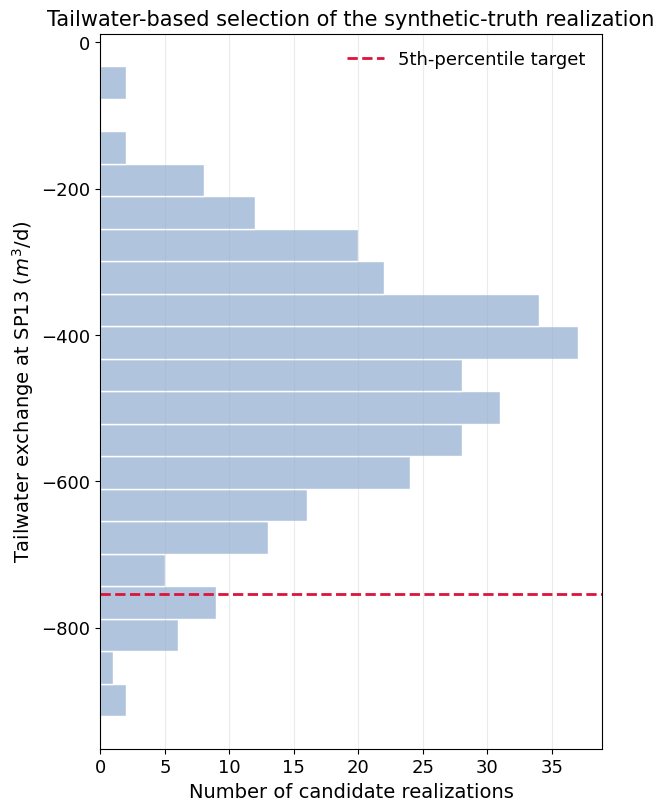

In [202]:
fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)

values = successful_candidates["tailwater_sp13"]

ax.hist(
    values,
    bins=20,
    orientation="horizontal",
    color="lightsteelblue",
    edgecolor="white",
)

# # 하위 5% 영역
# ax.axhspan(
#     values.min(),
#     tailwater_target,
#     color="lightgray",
#     alpha=0.6,
# )

ax.axhline(
    tailwater_target,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="5th-percentile target",
)


ax.set(
    title="Tailwater-based selection of the synthetic-truth realization",
    xlabel="Number of candidate realizations",
    ylabel=r"Tailwater exchange at SP13 ($m^3$/d)",
)



ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False)
plt.show()

57. Rebuild the selected realization as the final truth

The sweep reused one scratch workspace, so the selected realization's output files were
overwritten. We rebuild it once more into `final_truth/`. The inputs are identical fixed
arrays, so MODFLOW 6 reproduces the same outputs exactly. We also save the selected
realization's parameter fields alongside the run for provenance and the appendix checks.

In [203]:
reset_directory(FINAL_TRUTH_WS)

final_sim = flopy.mf6.MFSimulation.load(
    sim_ws=str(BASE_TRUTH_WS),
    verbosity_level=0,
)
final_gwf = final_sim.get_model()
final_sim.set_sim_path(str(FINAL_TRUTH_WS))

final_gwf.npf.k.set_data(hk_ensemble[selected_realization])
final_gwf.npf.k33.set_data(vk_ensemble[selected_realization])
final_gwf.sto.ss.set_data(ss_ensemble[selected_realization])

sy_selected = np.stack([
    sy_ensemble[selected_realization],
    np.zeros((nrow, ncol), dtype=float),
    np.zeros((nrow, ncol), dtype=float),
])
final_gwf.sto.sy.set_data(sy_selected)

final_rch_spd = {}
for kper in range(nper):
    final_rch_spd[kper] = np.where(
        idomain[0] > 0,
        recharge_ensemble[selected_realization, kper],
        0.0,
    )
final_gwf.rcha.recharge.set_data(final_rch_spd)

final_wel_spd = {}
for kper in range(nper):
    final_wel_spd[kper] = [
        [reference_well_cells[well_index], -pumping_ensemble[selected_realization, well_index, kper]]
        for well_index in range(len(reference_well_cells))
    ]
final_gwf.wel.stress_period_data.set_data(final_wel_spd)

final_sim.write_simulation()
final_sim.run_simulation(silent=True, report=True)

np.savez_compressed(
    FINAL_TRUTH_WS / "truth_parameters.npz",
    hk=hk_ensemble[selected_realization],
    vk=vk_ensemble[selected_realization],
    ss=ss_ensemble[selected_realization],
    sy=sy_ensemble[selected_realization],
    recharge=recharge_ensemble[selected_realization],
    pumping=pumping_ensemble[selected_realization],
)

58. Read the selected truth observations

In [204]:
truth_heads = read_mf6_observation_csv(FINAL_TRUTH_WS / "truth_heads_obs.csv")
truth_sfr = read_mf6_observation_csv(FINAL_TRUTH_WS / "truth_sfr_obs.csv")

truth_heads.insert(0, "sp", sp)
truth_heads.insert(1, "date", sp_dates)
truth_sfr.insert(0, "sp", sp)
truth_sfr.insert(1, "date", sp_dates)

59. Build noise-free synthetic history observations

In [218]:
history_rows = []

for current_sp in HISTORY_SP:
    row_index = current_sp - 1
    current_date = sp_dates[row_index]

    sw_value = float(truth_sfr.loc[row_index, "sw_1"])
    history_rows.append({
        "obsnme": f"sw_1_sp{current_sp:02d}",
        "obs_group": "streamflow",
        "sp": current_sp,
        "date": current_date,
        "observed": sw_value,
        "weight": 1.0 / (0.15 * abs(sw_value)),
        "source": "truth_sfr_obs.csv",
    })

    for obs_name in ["gw_1", "gw_2"]:
        head_value = float(truth_heads.loc[row_index, obs_name])
        history_rows.append({
            "obsnme": f"{obs_name}_sp{current_sp:02d}",
            "obs_group": "head",
            "sp": current_sp,
            "date": current_date,
            "observed": head_value,
            "weight": 1.0 / 0.15,
            "source": "truth_heads_obs.csv",
        })

history_observations = pd.DataFrame(history_rows)
history_observations.to_csv(HISTORY_OBS_CSV, index=False)

60. Build the three zero-weight forecast records

In [219]:
forecast_records = [
    {
        "obsnme": f"headwater_sp{HEADWATER_FORECAST_SP:02d}",
        "forecast_name": "headwater_exchange",
        "sp": HEADWATER_FORECAST_SP,
        "date": sp_dates[HEADWATER_FORECAST_SP - 1],
        "value": float(truth_sfr.loc[HEADWATER_FORECAST_SP - 1, "headwater_exchange"]),
        "weight": 0.0,
        "source": "truth_sfr_obs.csv",
    },
    {
        "obsnme": f"tailwater_sp{TAILWATER_FORECAST_SP:02d}",
        "forecast_name": "tailwater_exchange",
        "sp": TAILWATER_FORECAST_SP,
        "date": sp_dates[TAILWATER_FORECAST_SP - 1],
        "value": float(truth_sfr.loc[TAILWATER_FORECAST_SP - 1, "tailwater_exchange"]),
        "weight": 0.0,
        "source": "truth_sfr_obs.csv",
    },
    {
        "obsnme": f"gw_3_sp{GW3_FORECAST_SP:02d}",
        "forecast_name": "gw_3_head",
        "sp": GW3_FORECAST_SP,
        "date": sp_dates[GW3_FORECAST_SP - 1],
        "value": float(truth_heads.loc[GW3_FORECAST_SP - 1, "gw_3"]),
        "weight": 0.0,
        "source": "truth_heads_obs.csv",
    },
]

forecast_values = pd.DataFrame(forecast_records)
forecast_values.to_csv(FORECASTS_CSV, index=False)
forecast_values

,obsnme,forecast_name,sp,date,value,weight,source
0,headwater_sp22,headwater_exchange,22,2017-09-30,-590.775973,0.0,truth_sfr_obs.csv
1,tailwater_sp13,tailwater_exchange,13,2016-12-31,-754.290845,0.0,truth_sfr_obs.csv
2,gw_3_sp22,gw_3_head,22,2017-09-30,34.921403,0.0,truth_heads_obs.csv


61. Save reproducibility metadata

In [220]:
metadata = {
    "model_name": MODEL_NAME,
    "random_seed": RANDOM_SEED,
    "n_candidate_realizations": N_REALIZATIONS,
    "selected_realization": selected_realization,
    "selection_variable": "tailwater_exchange at SP13",
    "selection_quantile": 0.05,
    "spatial_exponential_range_m": SPATIAL_RANGE_M,
    "temporal_exponential_range_months": TEMPORAL_RANGE_MONTHS,
    "history_stress_periods": HISTORY_SP.tolist(),
    "headwater_forecast_sp": HEADWATER_FORECAST_SP,
    "tailwater_forecast_sp": TAILWATER_FORECAST_SP,
    "gw3_forecast_sp": GW3_FORECAST_SP,
    "observation_noise_added": False,
    "units": {
        "length": "m",
        "time": "d",
        "hydraulic_conductivity": "m/d",
        "specific_storage": "1/m",
        "well_rate": "m3/d",
        "recharge": "m/d",
    },
}

with open(TRUTH_METADATA, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, default=str)

62. Final forward-model deliverables

In [221]:
print("final MF6 truth workspace:", FINAL_TRUTH_WS)
print("candidate summary:", CANDIDATE_SUMMARY)
print("history observations:", HISTORY_OBS_CSV)
print("forecasts:", FORECASTS_CSV)
print("truth parameter draws:", PARAM_ENSEMBLE_NPZ)
print("metadata:", TRUTH_METADATA)

final MF6 truth workspace: C:\workspace\gwmodeling\model_enhanced_fr\runs\truth\final_truth
candidate summary: C:\workspace\gwmodeling\model_enhanced_fr\results\truth\truth_candidate_summary.csv
history observations: C:\workspace\gwmodeling\model_enhanced_fr\results\truth\synthetic_history_observations.csv
forecasts: C:\workspace\gwmodeling\model_enhanced_fr\results\truth\synthetic_forecasts.csv
truth parameter draws: C:\workspace\gwmodeling\model_enhanced_fr\results\truth\truth_parameter_ensembles.npz
metadata: C:\workspace\gwmodeling\model_enhanced_fr\results\truth\truth_metadata.json


63. final-truth verification

### Workspace files and `sw_1` inflow definition

In [222]:
required_files = [
    FINAL_TRUTH_WS / "truth_parameters.npz",
    FINAL_TRUTH_WS / "truth_heads_obs.csv",
    FINAL_TRUTH_WS / "truth_sfr_obs.csv",
    FINAL_TRUTH_WS / f"{MODEL_NAME}.hds",
    FINAL_TRUTH_WS / f"{MODEL_NAME}.cbc",
    FINAL_TRUTH_WS / "mfsim.lst",
]
assert all(path.exists() for path in required_files)

sfr_obs_lines = (FINAL_TRUTH_WS / f"{MODEL_NAME}.sfr.obs").read_text(errors="replace").splitlines()
assert any(("SW_1" in line.upper()) and ("INFLOW" in line.upper()) for line in sfr_obs_lines)

print("Final truth workspace files present; sw_1 INFLOW observation defined.")

Final truth workspace files present; sw_1 INFLOW observation defined.


### Property fields within TM bounds

In [223]:
with np.load(FINAL_TRUTH_WS / "truth_parameters.npz") as parameter_file:
    final_hk = parameter_file["hk"].copy()
    final_vk = parameter_file["vk"].copy()
    final_ss = parameter_file["ss"].copy()
    final_sy = parameter_file["sy"].copy()
    final_recharge = parameter_file["recharge"].copy()
    final_pumping = parameter_file["pumping"].copy()

truth_field_checks = [
    ("hk_l1", final_hk[0], 0),
    ("hk_l2", final_hk[1], 1),
    ("hk_l3", final_hk[2], 2),
    ("vk_l1", final_vk[0], 0),
    ("vk_l2", final_vk[1], 1),
    ("vk_l3", final_vk[2], 2),
    ("ss_l1", final_ss[0], 0),
    ("ss_l2", final_ss[1], 1),
    ("ss_l3", final_ss[2], 2),
    ("sy_l1", final_sy, 0),
]

tolerance = 1.0e-12
property_validation_records = []

for spec_name, field_array, lay in truth_field_checks:
    spec = property_table.loc[property_table["name"] == spec_name].iloc[0]
    active_values = field_array[idomain[lay] > 0]
    property_validation_records.append({
        "field": spec_name,
        "layer": lay + 1,
        "minimum": active_values.min(),
        "maximum": active_values.max(),
        "TM_lower_bound": float(spec.lower),
        "TM_upper_bound": float(spec.upper),
        "within_TM_bounds": bool(
            active_values.min() >= float(spec.lower) - tolerance
            and active_values.max() <= float(spec.upper) + tolerance
        ),
    })

property_validation = pd.DataFrame(property_validation_records)
assert property_validation["within_TM_bounds"].all()
property_validation

,field,layer,minimum,maximum,TM_lower_bound,TM_upper_bound,within_TM_bounds
0,hk_l1,1,3.000000e-01,25.525128,3.000000e-01,30.00000,True
1,hk_l2,2,3.000000e-02,2.338559,3.000000e-02,3.00000,True
2,hk_l3,3,3.000000e+00,300.000000,3.000000e+00,300.00000,True
3,vk_l1,1,3.000000e-02,3.000000,3.000000e-02,3.00000,True
4,vk_l2,2,3.000000e-03,0.300000,3.000000e-03,0.30000,True
5,vk_l3,3,3.000000e-01,30.000000,3.000000e-01,30.00000,True
6,ss_l1,1,1.000000e-07,0.000010,1.000000e-07,0.00001,True
7,ss_l2,2,1.000000e-07,0.000010,1.000000e-07,0.00001,True
8,ss_l3,3,1.000000e-07,0.000010,1.000000e-07,0.00001,True
9,sy_l1,1,1.000000e-03,0.100000,1.000000e-03,0.10000,True


### Final-truth property fields 

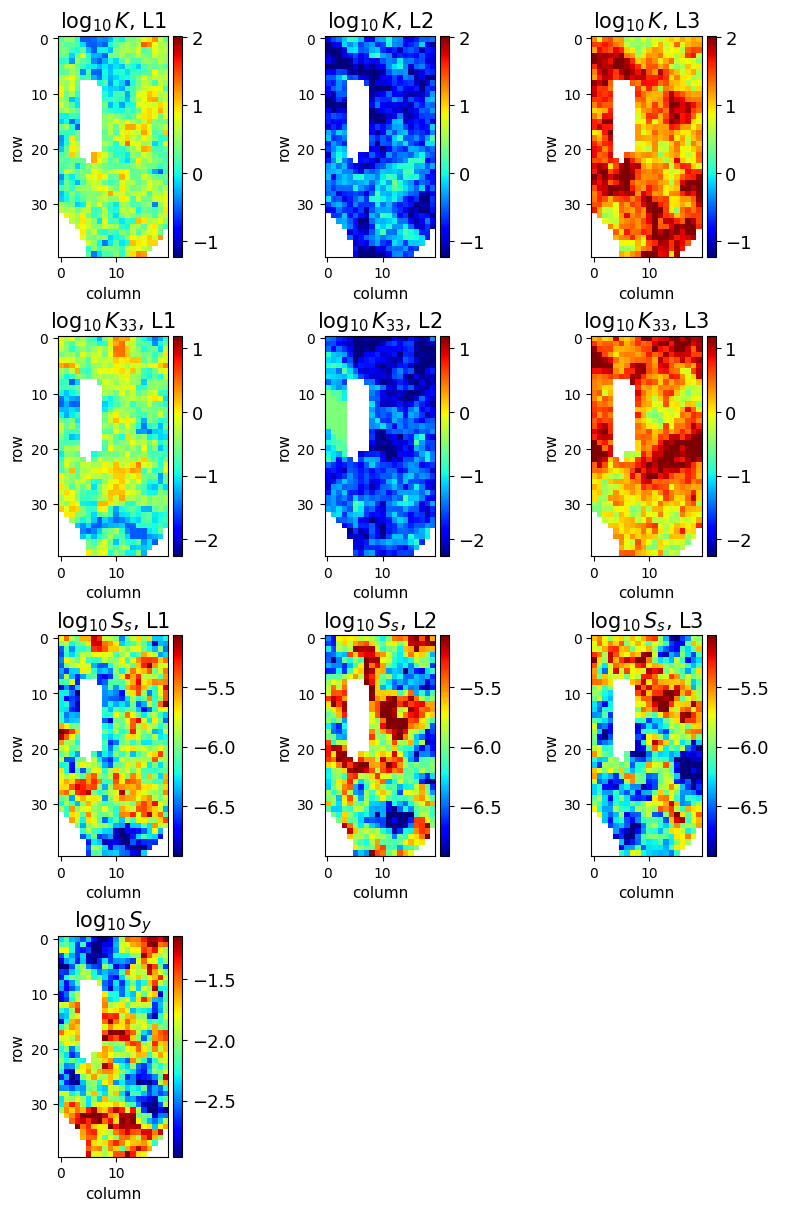

In [246]:
fig, axes = plt.subplots(4, 3, figsize=(8, 12), constrained_layout=True)

fields = [
    final_hk,
    final_vk,
    final_ss,
    final_sy
]

param_names = [
    r"$\log_{10} K$",
    r"$\log_{10} K_{33}$",
    r"$\log_{10} S_s$",
    r"$\log_{10} S_y$"
]

vmins = []
vmaxs = []

for i in range(4):

    if i == 3:
        arr = np.log10(fields[i])
        arr[idomain[0, :, :] <= 0] = np.nan
        vals = arr[np.isfinite(arr)]
    else:
        arr = np.log10(fields[i])
        arr[idomain <= 0] = np.nan
        vals = arr[np.isfinite(arr)]

    vmins.append(np.percentile(vals, 2))
    vmaxs.append(np.percentile(vals, 98))


for i in range(4):
    for j in range(3):

        ax = axes[i, j]

        if i == 3:
            if j != 0:
                ax.axis("off")
                continue

            field = np.log10(fields[i]).copy()
            field[idomain[0, :, :] <= 0] = np.nan

        else:
            field = np.log10(fields[i][j]).copy()
            field[idomain[j, :, :] <= 0] = np.nan

        im = ax.imshow(
        field,
        origin="upper",
        vmin=vmins[i],
        vmax=vmaxs[i],
        cmap="jet"
        )

        ax.tick_params(axis='both', which='major', labelsize=10)

        if i == 3:
            ax.set_title(param_names[i])
        else:
            ax.set_title(f"{param_names[i]}, L{j+1}")

        ax.set_xlabel("column", fontsize='11')
        ax.set_ylabel("row", fontsize='11')

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="8%", pad=0.05)
        fig.colorbar(im, cax=cax)

axes[3, 1].axis("off")
axes[3, 2].axis("off")

plt.show()

### Final-truth forcing: recharge and pumping (selected realization)

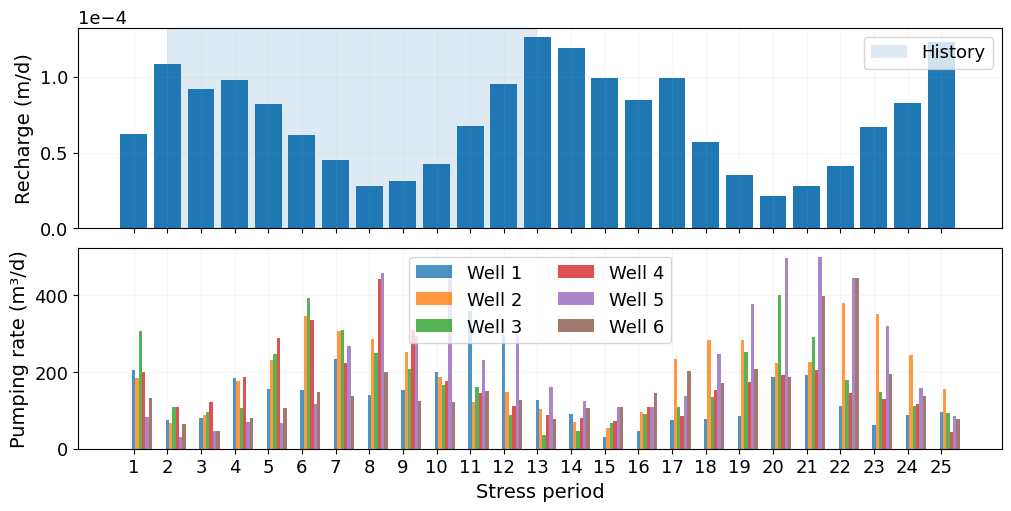

In [225]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, constrained_layout=True)

axes[0].bar(sp, final_recharge, width=0.8)
axes[0].set_ylabel("Recharge (m/d)")
axes[0].axvspan(2, 13, alpha=0.15, label="History")
axes[0].legend()
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[0].grid(True, linestyle="-", alpha=0.1)

for well_index in range(final_pumping.shape[0]):
    axes[1].bar(
        sp + well_index * 0.1,
        final_pumping[well_index],
        width=0.1,
        label=f"Well {well_index + 1}",
        alpha=0.8,
    )

axes[1].set_xlabel("Stress period")
axes[1].set_ylabel("Pumping rate (m³/d)")
axes[1].set_xticks(sp)
axes[1].legend(ncol=2)
axes[1].grid(True, linestyle="-", alpha=0.1)

plt.show()

### Observations & forecasts match the MF6 outputs

In [226]:
final_heads = read_mf6_observation_csv(FINAL_TRUTH_WS / "truth_heads_obs.csv")
final_sfr = read_mf6_observation_csv(FINAL_TRUTH_WS / "truth_sfr_obs.csv")

# Every saved history observation equals the MF6 output at its stress period.
for _, obs in history_observations.iterrows():
    row_index = int(obs["sp"]) - 1
    column = obs["obsnme"].rsplit("_sp", 1)[0]
    source = final_sfr if obs["obs_group"] == "streamflow" else final_heads
    np.testing.assert_allclose(obs["observed"], float(source.loc[row_index, column]), atol=1.0e-12)

# Every saved forecast equals the MF6 output at its forecast stress period.
forecast_source = {
    "headwater_exchange": (final_sfr, "headwater_exchange"),
    "tailwater_exchange": (final_sfr, "tailwater_exchange"),
    "gw_3_head": (final_heads, "gw_3"),
}
for _, fc in forecast_values.iterrows():
    row_index = int(fc["sp"]) - 1
    source, column = forecast_source[fc["forecast_name"]]
    np.testing.assert_allclose(fc["value"], float(source.loc[row_index, column]), atol=1.0e-12)

print("History observations and forecasts exactly match the final truth MF6 outputs.")

History observations and forecasts exactly match the final truth MF6 outputs.


### Global mass-balance discrepancy

In [227]:
import re

list_lines = (FINAL_TRUTH_WS / f"{MODEL_NAME}.lst").read_text(errors="replace").splitlines()

discrepancies = [
    float(match.group(1).replace("D", "E"))
    for line in list_lines
    if (match := re.search(
        r"PERCENT\s+DISCREPANCY\s*=\s*([-+]?(?:\d+\.?\d*|\.\d+)(?:[ED][-+]?\d+)?)",
        line.upper(),
    ))
]

assert discrepancies, "No PERCENT DISCREPANCY lines were found."
print(f"maximum absolute mass-balance discrepancy: {max(discrepancies, key=abs):.6g} %")

maximum absolute mass-balance discrepancy: -0.38 %


In [ ]:
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle,

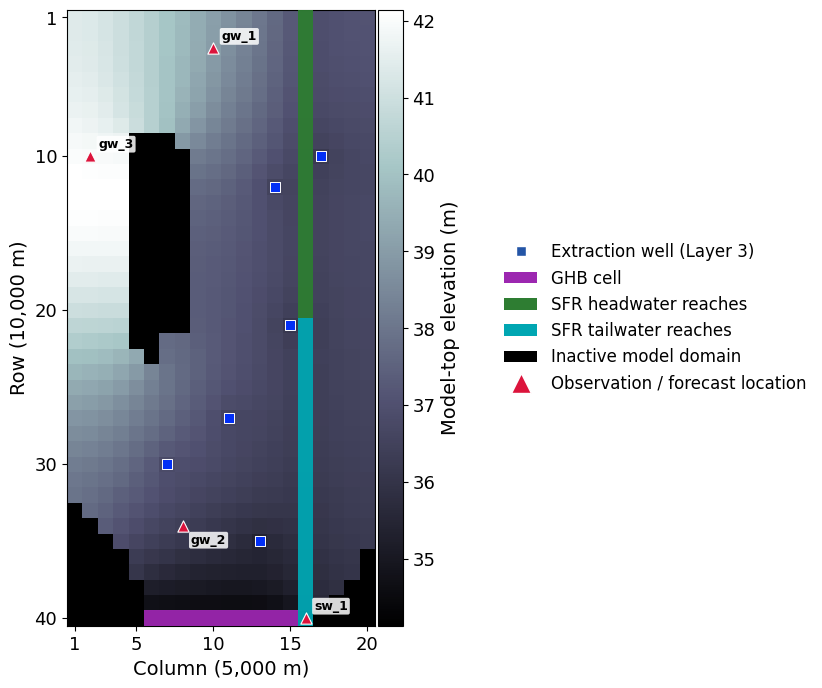

In [ ]:
Ly = nrow * delc

fig, ax = plt.subplots(figsize=(11.5, 8.0))

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="8%",
    pad=0.03,
)


lax = divider.append_axes(
    "right",
    size="34%",
    pad=2,
)

lax.axis("off")


def cell_center_xy(cellid):
    """Return the center of a MODFLOW cell in column-row coordinates."""
    _, row, col = map(int, cellid)
    return col + 0.5, row + 0.5


def add_cell_patch(ax, cellid, **kwargs):
    """Draw a MODFLOW cell footprint in column-row coordinates."""
    _, row, col = map(int, cellid)

    patch = Rectangle(
        (col, row),
        width=1.0,
        height=1.0,
        **kwargs,
    )
    ax.add_patch(patch)


top_plot = np.ma.masked_where(idomain[0] == 0, top)

top_cmap = plt.colormaps["bone"].copy()
top_cmap.set_bad("black")

im = ax.imshow(
    top_plot,
    origin="upper",
    extent=(0, ncol, nrow, 0),
    cmap=top_cmap,
    interpolation="none",
    aspect="equal",
    zorder=1,
)


ghb_plan_cells = sorted(
    {
        (int(cellid[1]), int(cellid[2]))
        for cellid, _, _ in ghb_spd
    }
)

for row, col in ghb_plan_cells:
    add_cell_patch(
        ax,
        (0, row, col),
        facecolor="#9c27b0",
        edgecolor="none",
        alpha=0.95,
        zorder=3,
    )


for reach in range(len(sfr_packagedata)):
    cellid = tuple(sfr_packagedata["cellid"][reach])

    sfr_color = "#2e7d32" if reach < 20 else "#00a6b2"

    add_cell_patch(
        ax,
        cellid,
        facecolor=sfr_color,
        edgecolor="none",
        alpha=0.95,
        zorder=4,
    )


for cellid in reference_well_cells:
    x, y = cell_center_xy(cellid)

    ax.scatter(
        x,
        y,
        marker="s",
        s=50,
        c="#022ff5",
        edgecolors="white",
        linewidths=0.7,
        zorder=6,
    )


point_cells = {
    "gw_1": GW_1,
    "gw_2": GW_2,
    "gw_3": GW_3,
    "sw_1": tuple(sfr_packagedata["cellid"][39]),
}

label_offsets = {
    "gw_1": (6, 6),
    "gw_2": (6, -13),
    "gw_3": (6, 6),
    "sw_1": (6, 6),
}

for name, cellid in point_cells.items():
    x, y = cell_center_xy(cellid)

    ax.scatter(
        x,
        y,
        marker="^",
        s=66,
        c="crimson",
        edgecolors="white",
        linewidths=0.8,
        zorder=7,
    )

    dx, dy = label_offsets[name]

    ax.annotate(
        name,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=8,
    )


ax.set(
    xlim=(0, ncol),
    ylim=(nrow, 0),
    xlabel=f"Column ({Lx:,.0f} m)",
    ylabel=f"Row ({Ly:,.0f} m)",
)

ax.set_xticks([0.5, 4.5, 9.5, 14.5, 19.5])
ax.set_xticklabels([1, 5, 10, 15, 20])

ax.set_yticks([0.5, 9.5, 19.5, 29.5, 39.5])
ax.set_yticklabels([1, 10, 20, 30, 40])


cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Model-top elevation (m)")


legend_handles = [
    Line2D(
        [],
        [],
        marker="s",
        linestyle="None",
        markersize=7,
        markerfacecolor="#2455a6",
        markeredgecolor="white",
        label="Extraction well (Layer 3)",
    ),
    Patch(facecolor="#9c27b0", label="GHB cell"),
    Patch(facecolor="#2e7d32", label="SFR headwater reaches"),
    Patch(facecolor="#00a6b2", label="SFR tailwater reaches"),
    Patch(facecolor="black", label="Inactive model domain"),
    Line2D(
        [],
        [],
        marker="^",
        linestyle="None",
        markersize=15,
        markerfacecolor="crimson",
        markeredgecolor="white",
        label="Observation / forecast location",
    ),
]

lax.legend(
    handles=legend_handles,
    # title="EXPLANATION",
    loc="center",
    frameon=False,
    fontsize=12,
    title_fontsize=9,
    borderaxespad=0.0,
)

plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


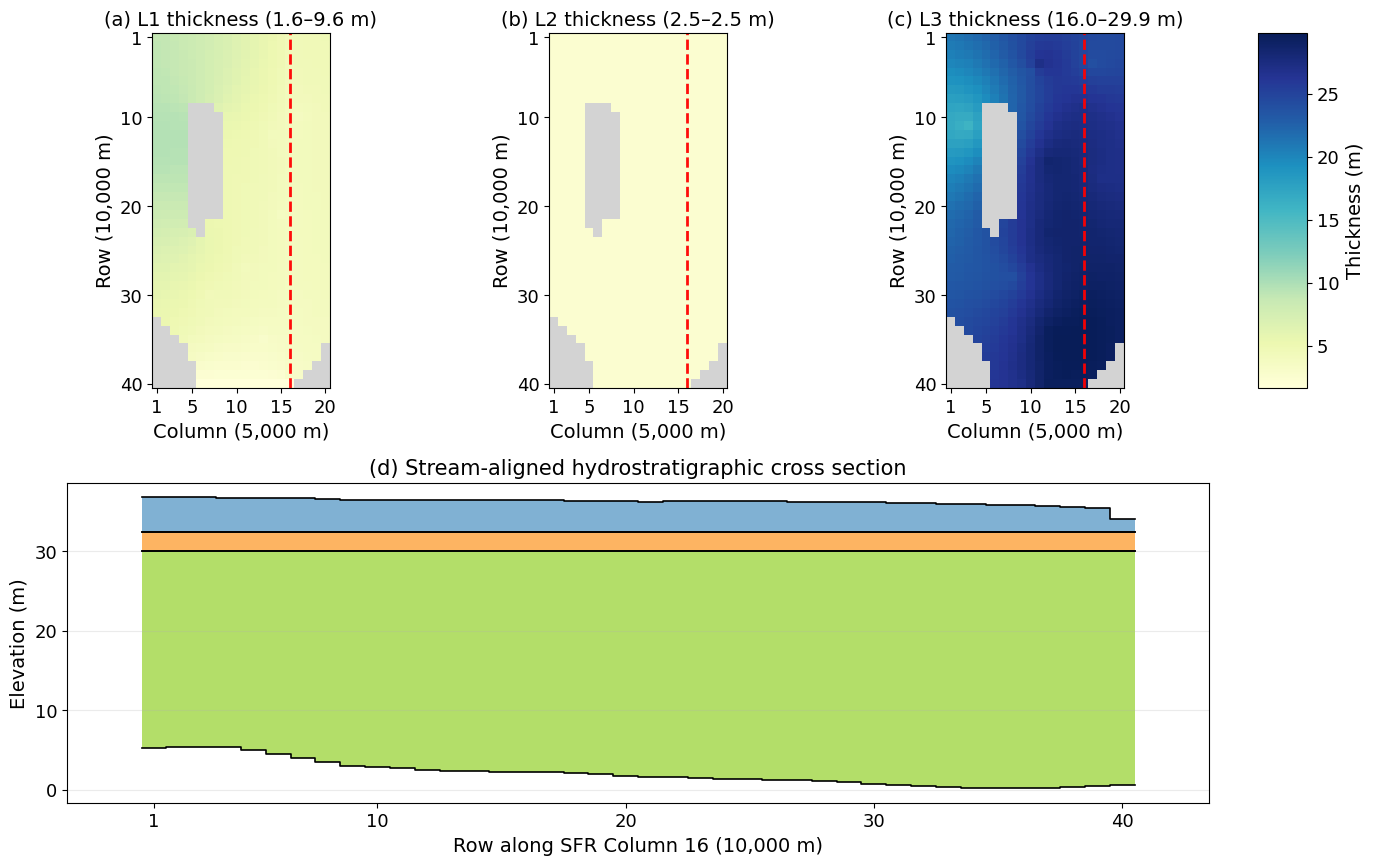

In [ ]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
})


delr_arr = (
    np.full(ncol, float(delr))
    if np.ndim(delr) == 0
    else np.asarray(delr, dtype=float).ravel()
)

delc_arr = (
    np.full(nrow, float(delc))
    if np.ndim(delc) == 0
    else np.asarray(delc, dtype=float).ravel()
)

Lx = delr_arr.sum()
Ly = delc_arr.sum()

thickness_l1 = top - botm[0]
thickness_l2 = botm[0] - botm[1]
thickness_l3 = botm[1] - botm[2]

active_l1 = idomain[0] > 0
active_l2 = idomain[1] > 0
active_l3 = idomain[2] > 0

def masked(array, active_mask):
    return np.ma.masked_where(~active_mask, array)



panels = [
    {
        "data": masked(thickness_l1, active_l1),
        "title": f"(a) L1 thickness ({thickness_l1[active_l1].min():.1f}–{thickness_l1[active_l1].max():.1f} m)",
    },
    {
        "data": masked(thickness_l2, active_l2),
        "title": f"(b) L2 thickness ({thickness_l2[active_l2].min():.1f}–{thickness_l2[active_l2].max():.1f} m)",
    },
    {
        "data": masked(thickness_l3, active_l3),
        "title": f"(c) L3 thickness ({thickness_l3[active_l3].min():.1f}–{thickness_l3[active_l3].max():.1f} m)",
    },
]

all_values = np.concatenate(
    [panel["data"].compressed() for panel in panels]
)

norm = Normalize(
    vmin=all_values.min(),
    vmax=all_values.max(),
)

cmap = plt.colormaps["YlGnBu"].copy()
cmap.set_bad("lightgray")



fig = plt.figure(figsize=(16, 10))

gs = fig.add_gridspec(
    nrows=2,
    ncols=4,
    height_ratios=[1.0, 0.9],
    width_ratios=[1.0, 1.0, 1.0, 0.14],
    hspace=0.28,
    wspace=0.18,
)

map_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax = fig.add_subplot(gs[0, 3])

ax_cross = fig.add_subplot(gs[1, :3])
lax = fig.add_subplot(gs[1, 3])
lax.axis("off")



x_ticks = [0.5, 4.5, 9.5, 14.5, 19.5]
x_labels = [1, 5, 10, 15, 20]

y_ticks = [0.5, 9.5, 19.5, 29.5, 39.5]
y_labels = [1, 10, 20, 30, 40]

sfr_col = 15

for ax, panel in zip(map_axes, panels):
    im = ax.imshow(
        panel["data"],
        origin="upper",
        extent=(0, ncol, nrow, 0),
        cmap=cmap,
        norm=norm,
        interpolation="none",
        aspect="equal",
    )
    ax.axvline(
        sfr_col + 0.5,
        color="red",
        linestyle="--",
        linewidth=2,
        alpha=0.95,
    )

    ax.set_title(panel["title"], fontsize=14)
    ax.set_xlabel(f"Column ({Lx:,.0f} m)")
    ax.set_ylabel(f"Row ({Ly:,.0f} m)")

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Thickness (m)", fontsize=14)
cbar.ax.tick_params(labelsize=13)


row_edges_m = np.concatenate([[0.0], np.cumsum(delc_arr)])
row_centers_m = 0.5 * (row_edges_m[:-1] + row_edges_m[1:])

top_xs = top[:, sfr_col]
botm1_xs = botm[0, :, sfr_col]
botm2_xs = botm[1, :, sfr_col]
botm3_xs = botm[2, :, sfr_col]

active1_xs = idomain[0, :, sfr_col] > 0
active2_xs = idomain[1, :, sfr_col] > 0
active3_xs = idomain[2, :, sfr_col] > 0


def extend_last(values):
    return np.append(values, values[-1])


def draw_layer(ax, upper, lower, active, label, facecolor):
    upper_e = extend_last(upper)
    lower_e = extend_last(lower)
    active_e = extend_last(active)

    ax.fill_between(
        row_edges_m,
        upper_e,
        lower_e,
        where=active_e,
        step="post",
        facecolor=facecolor,
        alpha=1.0,
        linewidth=0,
        label=label,
    )

    ax.step(
        row_edges_m,
        np.where(active_e, upper_e, np.nan),
        where="post",
        color="black",
        linewidth=1.2,
    )

    ax.step(
        row_edges_m,
        np.where(active_e, lower_e, np.nan),
        where="post",
        color="black",
        linewidth=1.2,
    )


draw_layer(
    ax_cross,
    top_xs,
    botm1_xs,
    active1_xs,
    "Layer 1: unconfined",
    "#80b1d3",
)

draw_layer(
    ax_cross,
    botm1_xs,
    botm2_xs,
    active2_xs,
    "Layer 2: confined",
    "#fdb462",
)

draw_layer(
    ax_cross,
    botm2_xs,
    botm3_xs,
    active3_xs,
    "Layer 3: confined",
    "#b3de69",
)

inactive_xs = ~(active1_xs | active2_xs | active3_xs)

for row in np.where(inactive_xs)[0]:
    ax_cross.axvspan(
        row_edges_m[row],
        row_edges_m[row + 1],
        color="white",
        alpha=1.0,
        linewidth=0,
    )

row_tick_numbers = [1, 10, 20, 30, 40]
row_tick_positions = [
    row_centers_m[row_number - 1]
    for row_number in row_tick_numbers
]

ax_cross.set(
    xlim=(0, Ly),
    xlabel=f"Row along SFR Column 16 ({Ly:,.0f} m)",
    ylabel="Elevation (m)",
    title="(d) Stream-aligned hydrostratigraphic cross section",
)

ax_cross.set_xticks(row_tick_positions)
ax_cross.set_xticklabels(row_tick_numbers)

ax_cross.grid(axis="y", alpha=0.25)

vertical_exaggeration = 80
ax_cross.set_aspect(vertical_exaggeration, adjustable="datalim")


legend_handles = [
    Patch(facecolor="#e6e6e6", edgecolor="black", label="Layer 1: unconfined"),
    Patch(facecolor="#cccccc", edgecolor="black", label="Layer 2: confined"),
    Patch(facecolor="#b3b3b3", edgecolor="black", label="Layer 3: confined"),
    Line2D([], [], color="black", linewidth=1.2, label="Layer interface"),
    Line2D([], [], color="white", linewidth=6, label="Inactive domain"),
    Line2D([], [], color="white", linestyle="--", linewidth=1.4, label="Cross-section trace"),
]


plt.show()